****COGNIFYZ INTERNSHIP MACHINE LEARNING INTERN****

**TASK 4: LOCATION-BASED ANALYSIS**

STEP 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STEP 2: Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/soumyasahoo23/restrruant-data/Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


STEP 3: Explore Latitude & Longitude

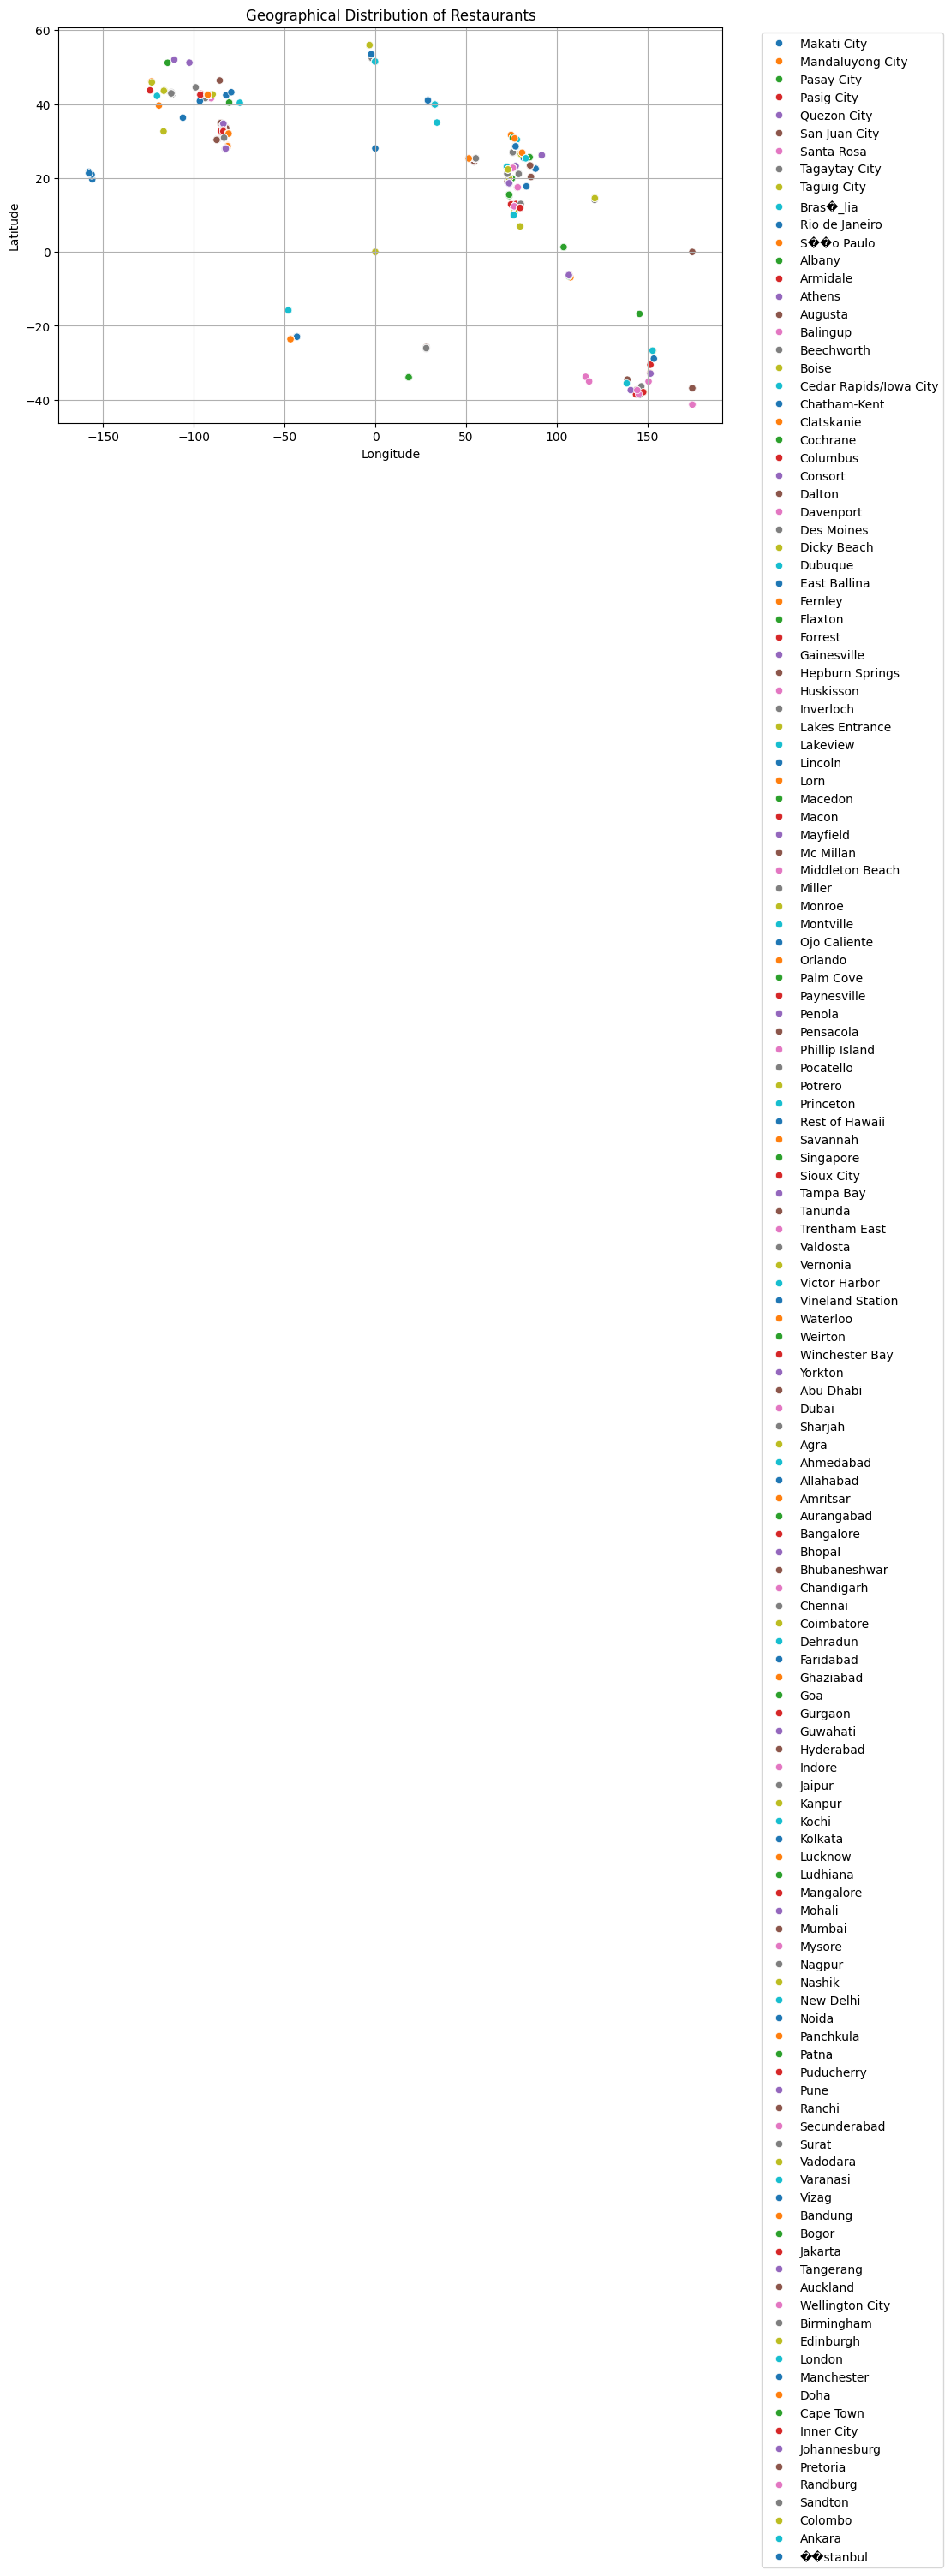

In [3]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Longitude'],
    y=df['Latitude'],
    hue=df['City'],
    palette='tab10'
)

plt.title("Geographical Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.show()

STEP 4: Restaurants per City

In [4]:
city_counts = df['City'].value_counts()

print("Number of Restaurants in Each City:\n")
print(city_counts)


Number of Restaurants in Each City:

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64


STEP 5: Average Rating & Price by City

In [5]:
city_stats = df.groupby('City').agg({
    'Aggregate rating': 'mean',
    'Price range': 'mean'
}).rename(columns={
    'Aggregate rating': 'Average Rating',
    'Price range': 'Average Price Range'
})

print("\nCity Statistics:\n")
display(city_stats)


City Statistics:



,Average Rating,Average Price Range
City,,
Abu Dhabi,4.300000,3.300000
Agra,3.965000,2.650000
Ahmedabad,4.161905,2.571429
Albany,3.555000,1.700000
Allahabad,3.395000,2.650000
...,...,...
Weirton,3.900000,2.000000
Wellington City,4.250000,3.250000
Winchester Bay,3.200000,2.000000


STEP 6: Cuisine Distribution

In [6]:
cuisine_distribution = pd.crosstab(df['City'], df['Cuisines'])

print("\nCuisine Distribution by City:\n")
print(cuisine_distribution)


Cuisine Distribution by City:

Cuisines         Afghani  Afghani, Mughlai, Chinese  Afghani, North Indian  \
City                                                                         
Abu Dhabi              0                          0                      0   
Agra                   0                          0                      0   
Ahmedabad              0                          0                      0   
Albany                 0                          0                      0   
Allahabad              0                          0                      0   
...                  ...                        ...                    ...   
Weirton                0                          0                      0   
Wellington City        0                          0                      0   
Winchester Bay         0                          0                      0   
Yorkton                0                          0                      0   
��stanbul              0        

STEP 7: Bar Plot

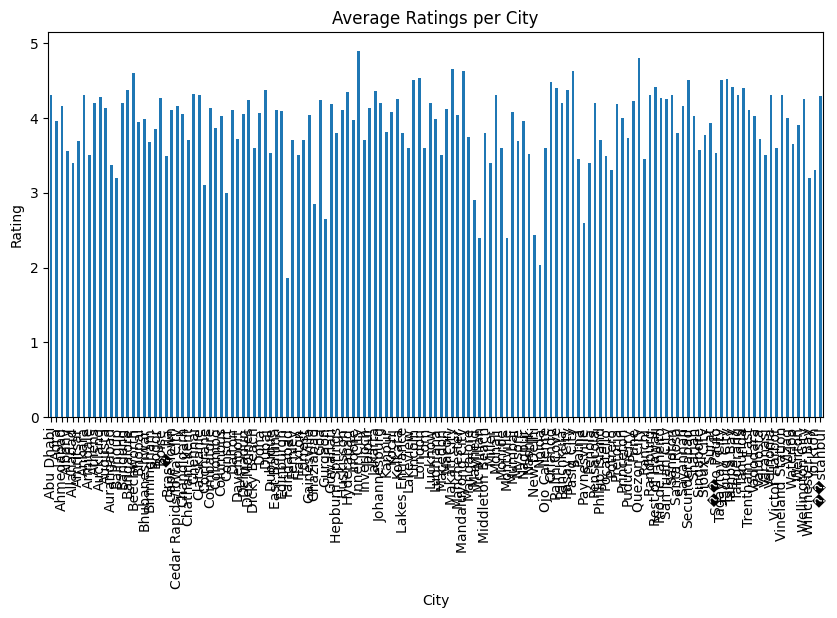

In [8]:
city_stats['Average Rating'].plot(
    kind='bar',
    figsize=(10,5),
    title="Average Ratings per City"
)

plt.ylabel("Rating")
plt.xlabel("City")
plt.xticks(rotation=90)
plt.show()